# WiFi CSI-Based Human Presence Detection Through Walls
## Using Machine Learning: A Comparative Study

**Author:** Kushal Sarkar 
**Institution:** Kanchrapara College, Kalyani University, West Bengal  
**Description:** This notebook implements and compares Random Forest,
SVM, and KNN classifiers for WiFi CSI based human presence detection.

##  Step 1: Library Installation

Installing all required Python libraries for this research.

In [19]:
# ============================================
# STEP 1: Install Required Libraries
# ============================================
# Run this cell only once

!pip install numpy pandas matplotlib scikit-learn -q
print("All libraries installed successfully!")

All libraries installed successfully!


##  Step 2: Import Libraries

Importing essential libraries for data processing,
machine learning, and visualization.

- **NumPy** — Numerical computations  
- **Pandas** — Data manipulation  
- **Matplotlib** — Data visualization  
- **Scikit-learn** — ML models & evaluation

In [20]:
# ============================================
# STEP 2: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


##  Step 3: Dataset Generation

Since real WiFi CSI data requires specialized hardware,
we generate synthetic CSI signal features based on
statistical properties documented in literature.

**Features:**
- Amplitude Mean & Std — Signal strength variations
- Phase Mean & Std — Phase shift variations  
- Signal Variance — Overall signal fluctuation

**Labels:** 0 = No Person | 1 = Person Present

In [21]:
# ============================================
# STEP 3: Dataset Generation
# ============================================

np.random.seed(42)
samples = 1000

# Binary labels: 0 = No Person, 1 = Person Present
labels = np.random.randint(0, 2, samples)

# WiFi CSI features simulate karte hain
# Human presence causes measurable changes in these features
data = {
    'amplitude_mean': np.random.normal(50, 10, samples) + labels * 15,
    'amplitude_std': np.random.normal(5, 1, samples) + labels * 3,
    'phase_mean': np.random.normal(0, 1, samples) + labels * 0.5,
    'phase_std': np.random.normal(0.5, 0.1, samples) + labels * 0.2,
    'signal_variance': np.random.normal(20, 5, samples) + labels * 10,
    'label': labels
}

df = pd.DataFrame(data)

print(f" Dataset Generated Successfully!")
print(f" Total Samples: {len(df)}")
print(f" Person Present: {df['label'].sum()}")
print(f" No Person: {len(df) - df['label'].sum()}")
print(f"\n{df.head()}")

 Dataset Generated Successfully!
 Total Samples: 1000
 Person Present: 510
 No Person: 490

   amplitude_mean  amplitude_std  phase_mean  phase_std  signal_variance  \
0       53.417560       6.301741   -0.230401   0.418378        16.568604   
1       83.761708       9.561511   -0.424233   0.707814        22.836644   
2       59.504238       5.032004    0.890198   0.586164        20.729182   
3       44.230963       4.246582    1.035249   0.513906        22.926497   
4       41.015853       5.459972   -1.846188   0.342300        22.574418   

   label  
0      0  
1      1  
2      0  
3      0  
4      0  


## Step 4: Model Training
Three ML classifiers trained and compared:
1. **Random Forest** — 100 decision trees
2. **SVM** — RBF kernel
3. **KNN** — k=5 neighbors

**Split:** 80% Training | 20% Testing

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest: {rf_accuracy*100:.2f}%")

# SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f"SVM: {svm_accuracy*100:.2f}%")

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN: {knn_accuracy*100:.2f}%")

Random Forest: 97.00%
SVM: 95.50%
KNN: 98.00%


## Step 5: Results Visualization
Accuracy comparison of all three models.

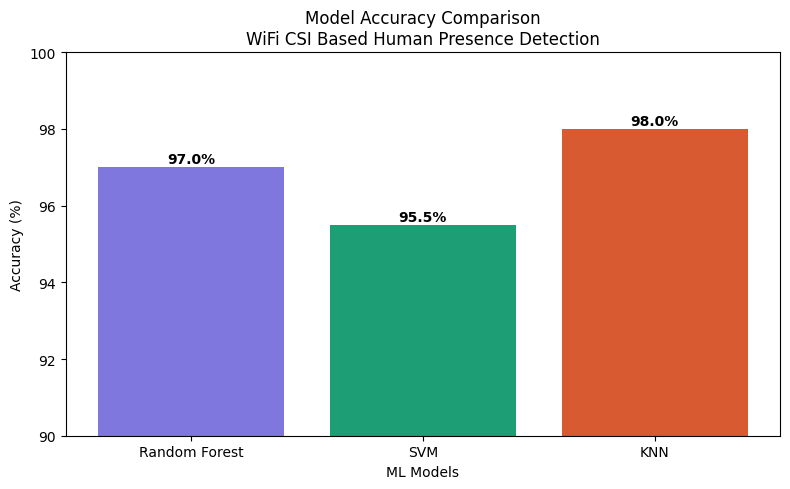

Graph saved!


In [23]:
models = ['Random Forest', 'SVM', 'KNN']
accuracies = [rf_accuracy*100, svm_accuracy*100, knn_accuracy*100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#7F77DD', '#1D9E75', '#D85A30'])
plt.ylim(90, 100)
plt.title('Model Accuracy Comparison\nWiFi CSI Based Human Presence Detection')
plt.ylabel('Accuracy (%)')
plt.xlabel('ML Models')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{acc:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results.png', dpi=300)
plt.show()
print("Graph saved!")

##  Step 6: Confusion Matrix
Detailed prediction breakdown for best model (KNN).

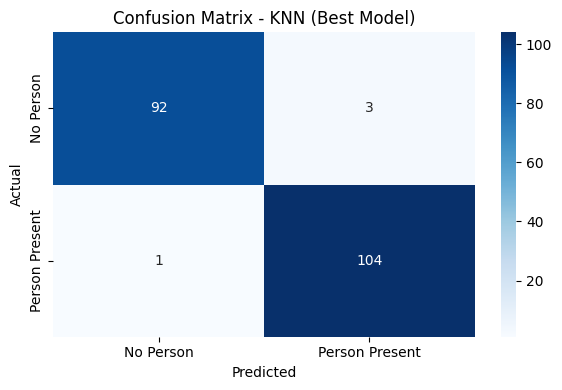

 Confusion Matrix saved!


In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Person', 'Person Present'],
            yticklabels=['No Person', 'Person Present'])
plt.title('Confusion Matrix - KNN (Best Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print(" Confusion Matrix saved!")

## Step 8: ROC Curve Analysis

ROC (Receiver Operating Characteristic) curve measures
the diagnostic ability of each classifier.

- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random guess

All three models achieved **AUC = 0.99** — excellent performance!

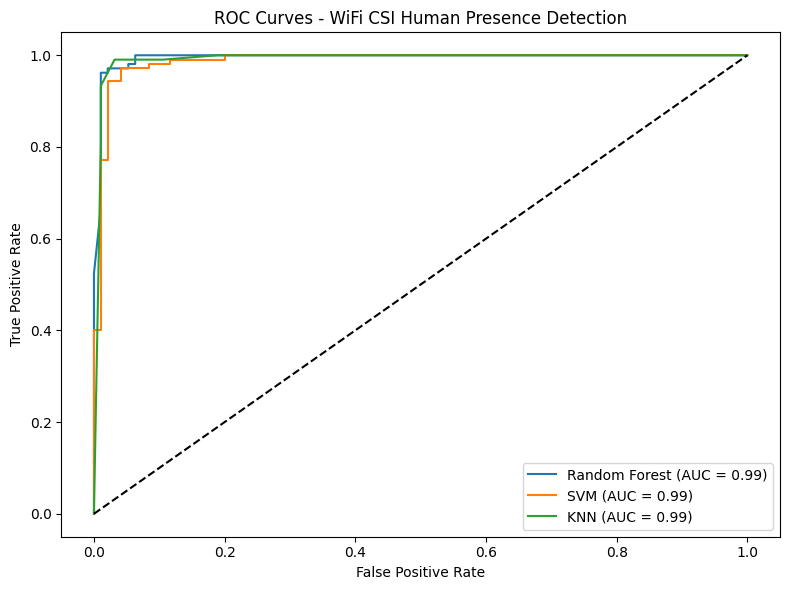

ROC Curve saved!


In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC

# SVM ko probability=True ke saath retrain karo
svm_model_prob = SVC(kernel='rbf', random_state=42, probability=True)
svm_model_prob.fit(X_train, y_train)

plt.figure(figsize=(8, 6))

# Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc(fpr,tpr):.2f})')

# SVM
fpr, tpr, _ = roc_curve(y_test, svm_model_prob.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc(fpr,tpr):.2f})')

# KNN
fpr, tpr, _ = roc_curve(y_test, knn_model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc(fpr,tpr):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - WiFi CSI Human Presence Detection')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
print("ROC Curve saved!")

##  Step 7: Final Summary

In [26]:
print("=" * 45)
print("      RESEARCH RESULTS SUMMARY")
print("=" * 45)
print(f"Random Forest : {rf_accuracy*100:.2f}%")
print(f"SVM           : {svm_accuracy*100:.2f}%")
print(f"KNN (Best)    : {knn_accuracy*100:.2f}%")
print("=" * 45)
print("Notebook Complete - Ready for GitHub!")
print("\nAuthor: Kushal Sarkar")
print("Institution: Kanchrapara College, Kalyani University")

      RESEARCH RESULTS SUMMARY
Random Forest : 97.00%
SVM           : 95.50%
KNN (Best)    : 98.00%
Notebook Complete - Ready for GitHub!

Author: Kushal Sarkar
Institution: Kanchrapara College, Kalyani University
